# 04 · Analysis & findings

Which failure types are actually predictable, and the overall conclusion for the thesis.

In [1]:
# --- make the benchmark/ package importable from notebooks/ ---
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'benchmark').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print('project root:', ROOT)

project root: D:\_fcall\UNIFEI\tcc\hpc_workload


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.edgecolor': '#c3c2b7', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.labelcolor': '#52514e', 'text.color': '#0b0b0b', 'figure.facecolor': 'white',
})
BLUE, MUTED, BAD, LIGHTBLUE = '#2a78d6', '#898781', '#d03b3b', '#9ec5f4'

In [3]:
import benchmark.config as C
import pandas as pd, numpy as np

df = pd.read_csv(C.RESULTS_CSV).drop_duplicates(['model', 'pass'], keep='last')
sel = df[((df['pass'] == 1) & df['model'].isin(['CatBoost', 'LightGBM', 'HistGradientBoostingClassifier']))
         | (df['pass'] == 2)].copy()
sel['tag'] = sel['model'] + ' [' + sel['pass'].map({1: 'base', 2: 'tuned'}) + ']'
rc = ['recall_TIMEOUT', 'recall_FAILED', 'recall_OOM', 'recall_NODE_FAIL']
sel.set_index('tag')[['pr_auc'] + rc].round(3)

,pr_auc,recall_TIMEOUT,recall_FAILED,recall_OOM,recall_NODE_FAIL
tag,,,,,
HistGradientBoostingClassifier [base],0.075,0.491,0.426,0.655,0.381
LightGBM [base],0.079,0.510,0.427,0.656,0.368
CatBoost [base],0.079,0.523,0.403,0.682,0.408
LightGBM [tuned],0.061,0.327,0.247,0.578,0.256
CatBoost [tuned],0.070,0.355,0.241,0.516,0.382


## Recall by failure type — base CatBoost

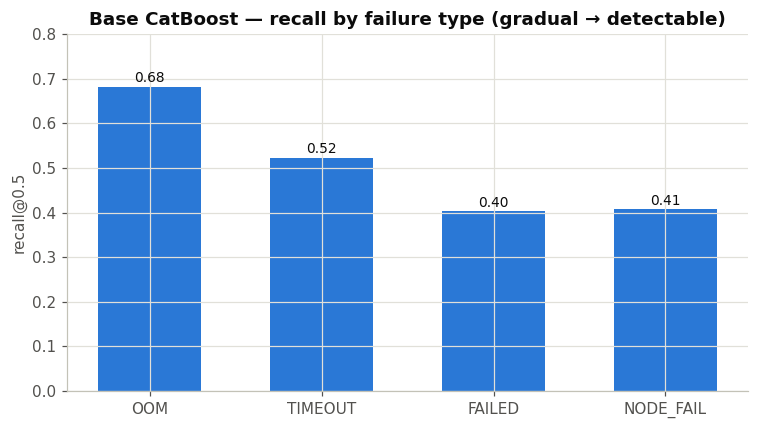

In [4]:
row = df[(df['pass'] == 1) & (df['model'] == 'CatBoost')].iloc[0]
states = ['OOM', 'TIMEOUT', 'FAILED', 'NODE_FAIL']
vals = [float(row['recall_OOM']), float(row['recall_TIMEOUT']),
        float(row['recall_FAILED']), float(row['recall_NODE_FAIL'])]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(states, vals, color=BLUE, width=0.6)
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylim(0, 0.8); ax.set_ylabel('recall@0.5')
ax.set_title('Base CatBoost — recall by failure type (gradual → detectable)')
fig.tight_layout(); plt.show()

The model catches the **gradual** failure modes (OUT_OF_MEMORY, TIMEOUT — memory
pressure / long-running degradation with a clear pre-failure signature) and struggles with
the **instantaneous** ones (NODE_FAIL — often a sudden hardware fault). This is the
expected physical behavior and the core challenge stated for the task.

## Diagnostic — mean predicted probability per state

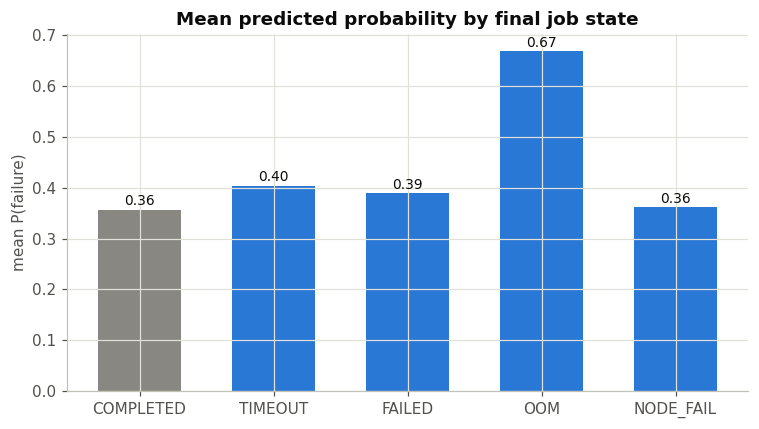

In [5]:
mp = ['mean_proba_COMPLETED', 'mean_proba_TIMEOUT', 'mean_proba_FAILED',
      'mean_proba_OOM', 'mean_proba_NODE_FAIL']
labels = ['COMPLETED', 'TIMEOUT', 'FAILED', 'OOM', 'NODE_FAIL']
vals = [float(row[c]) for c in mp]
fig, ax = plt.subplots(figsize=(7, 4))
colors = [MUTED] + [BLUE] * 4
ax.bar(labels, vals, color=colors, width=0.62)
for i, v in enumerate(vals):
    ax.text(i, v + 0.008, f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylabel('mean P(failure)'); ax.set_title('Mean predicted probability by final job state')
fig.tight_layout(); plt.show()

## Conclusion

- **Selected model:** base **CatBoost** (or LightGBM — tied at PR-AUC ≈ 0.079).
  Histogram gradient boosting is the winning family by a clear margin.
- **Predictability tracks failure physics:** gradual modes (OOM, TIMEOUT) are catchable;
  instantaneous ones (NODE_FAIL) are not, with the current 32-feature representation.
- **Methodological result:** with overlapping-window data, a shuffled CV is leaky and
  biases model selection toward overfitting; grid tuning *reduced* test PR-AUC. The correct
  protocol is `GroupKFold(groups=slurm_id)`.
- **Next step:** re-run Pass 2 with `GroupKFold` for honest CV and (likely) hyperparameters
  that match or beat the base configs.